In [27]:
# import re
# import numpy as np
# import pandas as pd
# from scipy import stats
# import matplotlib.pyplot as plt
# %matplotlib inline

In [28]:
import pandas as pd
data = pd.read_csv('dog_rates_tweets.csv')
data.head()

,id,created_at,text
0,994677639364403200,2018-05-10 20:36:44,@Steff88979267 tell them to h*ck off
1,994364904978239488,2018-05-09 23:54:02,@NFLOwnerGBP take it back
2,994363623421153280,2018-05-09 23:48:56,This is Louie. He has misplaced his Cheerio. W...
3,994336722875047936,2018-05-09 22:02:03,@rachaellanaghan ❤️
4,994024065982717952,2018-05-09 01:19:40,This is Captain Jack Wobbles. He is currently ...


In [29]:
data['created_at'] = pd.to_datetime(data['created_at'], format='ISO8601', utc=True)
data.head()

,id,created_at,text
0,994677639364403200,2018-05-10 20:36:44+00:00,@Steff88979267 tell them to h*ck off
1,994364904978239488,2018-05-09 23:54:02+00:00,@NFLOwnerGBP take it back
2,994363623421153280,2018-05-09 23:48:56+00:00,This is Louie. He has misplaced his Cheerio. W...
3,994336722875047936,2018-05-09 22:02:03+00:00,@rachaellanaghan ❤️
4,994024065982717952,2018-05-09 01:19:40+00:00,This is Captain Jack Wobbles. He is currently ...


get the rating

tweets with “/10” rating, get numeric value   
exclude tweets without a rating.

In [30]:
import re

In [31]:
rating_re = re.compile(r'(\d+(\.\d+)?)/10')

def get_rating(text):
    m = rating_re.search(text)
    if m:
        return float(m.group(1))
    return None

data['rating'] = data['text'].apply(get_rating)
data = data[data['rating'].notnull()]

remove outliers

(Maybe larger than 25/10?)

In [32]:
data = data[data['rating'] <= 25]

scatter plot of date vs. rating.

In [33]:
import matplotlib.pyplot as plt

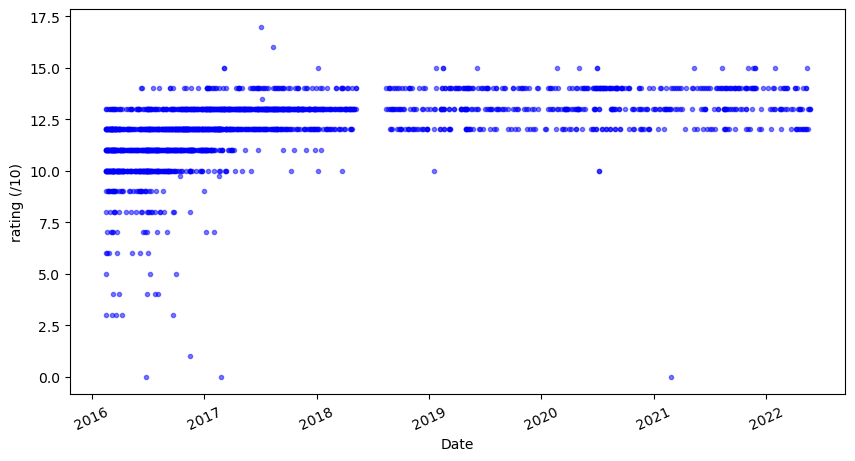

In [34]:
plt.figure(figsize=(10, 5))
plt.xticks(rotation=25)
plt.plot(data['created_at'], data['rating'], 'b.', alpha=0.5)

plt.xlabel('Date')
plt.ylabel('rating (/10)')

plt.show()

linear regeresion

In [35]:
def to_timestamp(d):
    return d.timestamp()

data['timestamp'] = data['created_at'].apply(to_timestamp)

In [36]:
from scipy import stats

In [37]:
fit = stats.linregress(data['timestamp'], data['rating'])

results

In [38]:
data['prediction'] = data['timestamp'] * fit.slope + fit.intercept

In [39]:
data

,id,created_at,text,rating,timestamp,prediction
2,994363623421153280,2018-05-09 23:48:56+00:00,This is Louie. He has misplaced his Cheerio. W...,14.0,1.525910e+09,12.303448
7,993889039714578432,2018-05-08 16:23:07+00:00,This is Manny. He hasn’t seen your croissant. ...,13.0,1.525797e+09,12.301750
8,993629544463642624,2018-05-07 23:11:58+00:00,This is Libby. She leap. 14/10\n(IG: libbythef...,14.0,1.525735e+09,12.300822
24,992198572664860672,2018-05-04 00:25:48+00:00,This is Rosie. She thought Coachella was this ...,13.0,1.525394e+09,12.295704
30,991744041351090177,2018-05-02 18:19:39+00:00,This is Riley. He’ll be your chauffeur this ev...,13.0,1.525285e+09,12.294079
...,...,...,...,...,...,...
14885,1275493485085245440,2020-06-23 18:18:39+00:00,This is Ruth. She was spotted at a rally doing...,14.0,1.592936e+09,13.308880
14895,1275102054608855040,2020-06-22 16:23:14+00:00,This is Narcos. He is very angry with you. The...,13.0,1.592843e+09,13.307480
14896,1274821722584125442,2020-06-21 21:49:18+00:00,@PatrickKenneyMD omg i’d say 13/10 but i’d hat...,13.0,1.592776e+09,13.306478
14906,1273774320519483392,2020-06-19 00:27:18+00:00,This is Oakley. He’s on his way home for the f...,12.0,1.592526e+09,13.302732


In [40]:
fit.slope, fit.intercept

(1.5000503986105543e-08, -10.585967528906664)

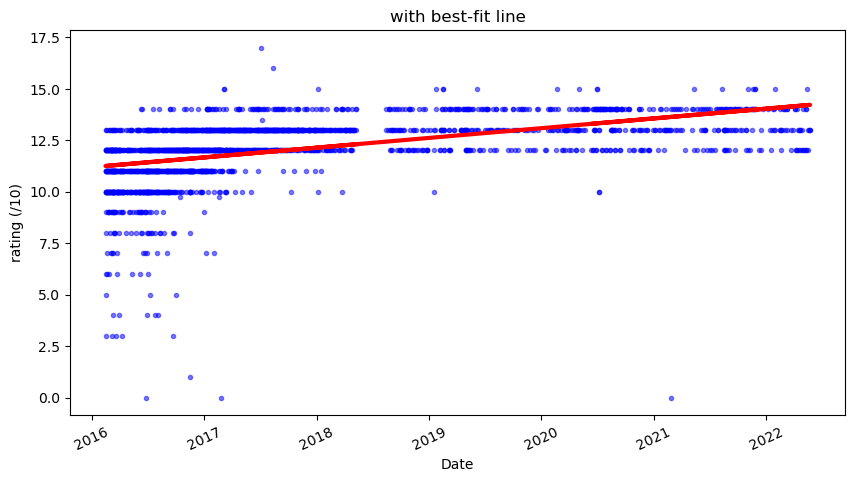

In [41]:
plt.figure(figsize=(10, 5))
plt.xticks(rotation=25)
plt.plot(data['created_at'], data['rating'], 'b.', alpha=0.5)
plt.plot(data['created_at'], data['timestamp'] * fit.slope + fit.intercept, 'r-', linewidth=3)
plt.xlabel('Date')
plt.ylabel('rating (/10)')

plt.title('with best-fit line')
plt.show()

with ignificance  

p-value from the regression 

In [42]:
fit.pvalue

2.6070388139659223e-127

The OLS p value is ok if  residuals are approximately normal

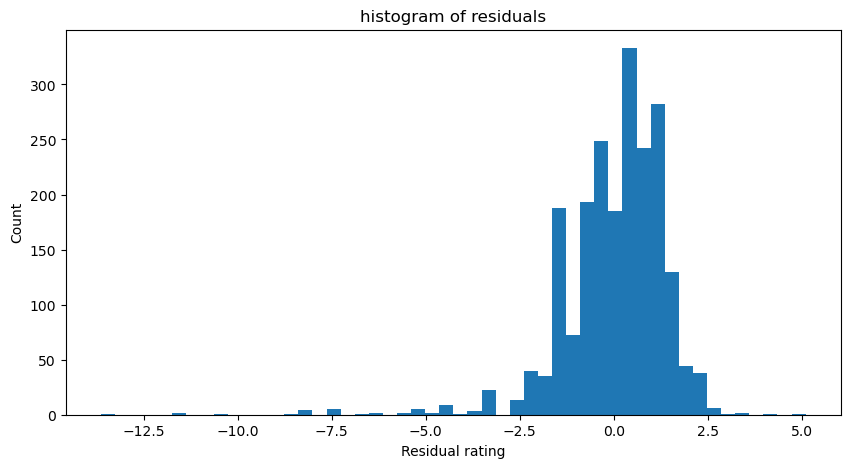

In [43]:
residuals = data['rating'] - data['prediction']
plt.figure(figsize=(10, 5))
plt.hist(residuals, bins=50)
plt.xlabel('Residual rating')
plt.ylabel('Count')

plt.title('histogram of residuals')
plt.show()